In [1]:
import pandas as pd             
import xarray as xr            
import numpy as np             
import matplotlib.pyplot as plt     
import seaborn as sns

from numpy.linalg import matrix_rank

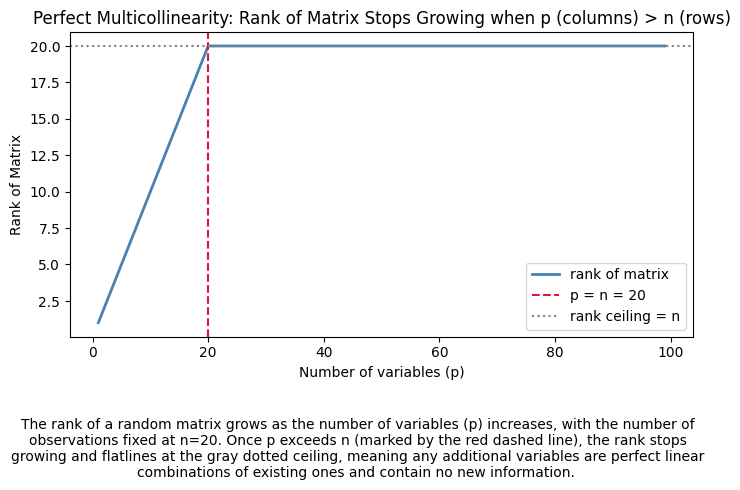

<Figure size 640x480 with 0 Axes>

In [17]:
#This loop creates a random dataset with p columns. Each iteration creates a matrix with n = 20 rows, and the number of columns p 
#which grows incrementaly. At 20 columns, the rank, or the number of independent columns reaches it's max, after which the 
#data has perfect multicollinearity, i.e. the additional columns can be produced by multiples of the other columns, and therefore
#do not yield any more additional information. 

results = []
for p in range(1, 100):
    X = np.random.randn(20, p)
    results.append({"p": p, "rank": matrix_rank(X)})

df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df["p"], df["rank"], color="steelblue", lw=2, label="rank of matrix")
ax.axvline(x=20, color="crimson", linestyle="--", label="p = n = 20")
ax.axhline(y=20, color="gray", linestyle=":", label="rank ceiling = n")
ax.set_xlabel("Number of variables (p)")
ax.set_ylabel("Rank of Matrix")
ax.set_title("Perfect Multicollinearity: Rank of Matrix Stops Growing when p (columns) > n (rows)")
ax.legend()
plt.subplots_adjust(bottom=0.5)
fig.text(0.5, -0.2, 
         """The rank of a random matrix grows as the number of variables (p) increases, """
         """with the number of observations fixed at n=20. Once p exceeds n (marked by the red dashed line), """
         """the rank stops growing and flatlines at the gray dotted ceiling, meaning any additional variables """
         """are perfect linear combinations of existing ones and contain no new information. """,
         ha="center", fontsize=10, color="black", wrap=True)
plt.tight_layout()
plt.show()

#Save figure
plt.savefig("Sofia_Vakh_CoD_Figure.pdf", bbox_inches="tight")

In [18]:
# Claude AI was used to help generate the code for plotting.